In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_data= ("../data/chest_xray/train")
test_data=("../data/chest_xray/test")
val_data=("../data/chest_xray/val")

In [3]:
train_datagen= ImageDataGenerator(
    rescale= 1./255, 
    rotation_range= 20, 
    zoom_range=0.2, 
    width_shift_range=0.1, 
    height_shift_range=0.1,
    horizontal_flip=True
    )

test_datagen= ImageDataGenerator(
    rescale= 1./255
)

In [4]:
train_image= train_datagen.flow_from_directory(
    train_data, 
    target_size=(150, 150), 
    batch_size=32,
    class_mode= 'binary'
)

test_image= test_datagen.flow_from_directory(
    test_data, 
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_image= test_datagen.flow_from_directory(
    val_data,
    target_size=(150, 150),
    batch_size=32, 
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [5]:
print(train_image.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


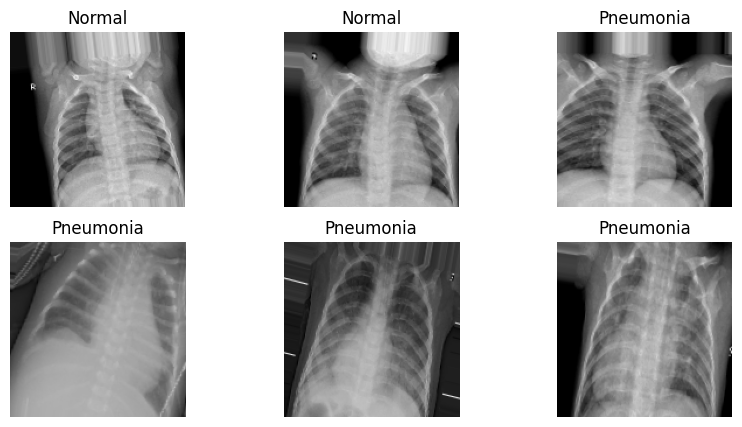

In [6]:
images, labels= next(train_image)

plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] ==1 else "Normal")
    plt.axis("off")
    
plt.show()

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.layers import BatchNormalization

In [8]:
model=Sequential()

In [9]:
model.add(
    Conv2D(
        32, 
        (3,3),
        activation= 'relu',
        input_shape= (150,150,3)
    )
)

/opt/anaconda3/envs/pneumonia/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.add(BatchNormalization())

In [11]:
model.add(MaxPooling2D(2,2))

In [12]:
model.add(Conv2D (64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D (2,2))

In [13]:
model.add(Conv2D (128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D (2,2))

In [14]:
model.add(Flatten())

In [15]:
model.add(Dense(64, activation= 'relu'))
model.add(Dropout(0.5))
model.add(Dense (1, activation = 'sigmoid'))

In [16]:
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics= ['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,367,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,461,761 (9.39 MB)

 Trainable params: 2,461,313 (9.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
early_stop=EarlyStopping(
    monitor= 'val_loss',
    patience=2,
    restore_best_weights=True
)

In [20]:
history= model.fit(
    train_image, 
    validation_data= val_image,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 239ms/step - accuracy: 0.8133 - loss: 0.5464 - val_accuracy: 0.5000 - val_loss: 42.7325
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.8687 - loss: 0.3312 - val_accuracy: 0.5000 - val_loss: 35.3153
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 257ms/step - accuracy: 0.8867 - loss: 0.2581 - val_accuracy: 0.5000 - val_loss: 10.2698
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 254ms/step - accuracy: 0.8955 - loss: 0.2636 - val_accuracy: 0.6250 - val_loss: 2.5663
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 260ms/step - accuracy: 0.9018 - loss: 0.2401 - val_accuracy: 0.5000 - val_loss: 0.7403
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 260ms/step - accuracy: 0.9076 - loss: 0.2285 - val_accuracy: 0.5625 - val_loss: 2.8056
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step - accuracy: 0.9191 - loss: 0.2193 - val_accuracy: 0.5000 - val_loss: 14.1838


In [21]:
test_loss, test_accuracy= model.evaluate(test_image)

print("Test Loss: ", test_loss)
print("Test Accuracy", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.7548 - loss: 0.4941
Test Loss:  0.49409621953964233
Test Accuracy 0.754807710647583


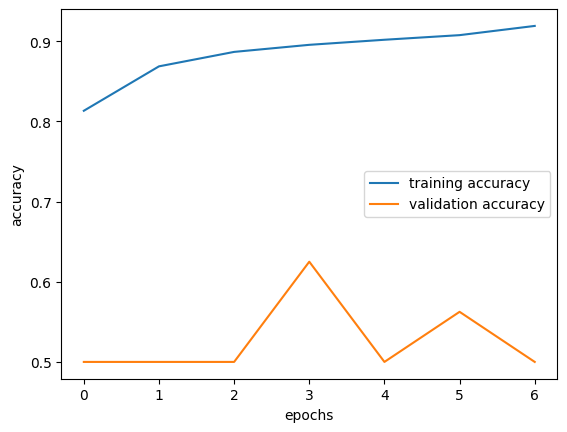

In [22]:
plt.plot(history.history['accuracy'], label= 'training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.show()

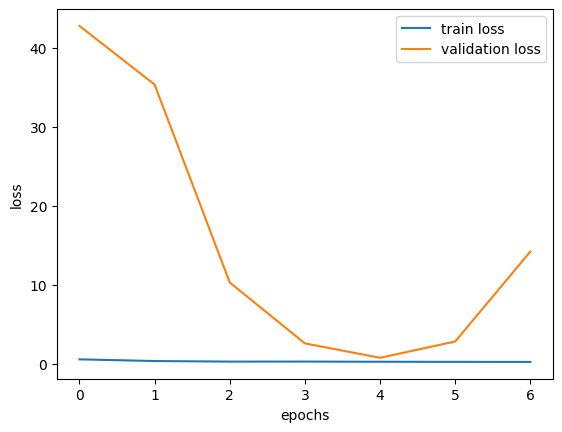

In [23]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

In [24]:
predictions= model.predict(test_image)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step


In [25]:
predicted_classes=(predictions>0.5).astype('int32')

In [26]:
true_samples= test_image.classes

In [27]:
from sklearn.metrics import(
    classification_report, 
    confusion_matrix
)

In [28]:
print(classification_report(true_samples, predicted_classes))

              precision    recall  f1-score   support

           0       0.39      0.47      0.43       234
           1       0.64      0.55      0.59       390

    accuracy                           0.52       624
   macro avg       0.51      0.51      0.51       624
weighted avg       0.54      0.52      0.53       624



In [29]:
model.save('../model/pneumoniav1.h5')